In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
H = nx.read_graphml('springRest_wdata1.gml')
G = nx.Graph(H) # create an undirected graph G from a directed graph H

G.number_of_edges() #184
G.number_of_nodes() #102

102

In [3]:
def draw_graph(graph, title="", mylabels={}):
    pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2)
    plt.figure(1,figsize=(20,30))
    nx.draw(graph,
        pos = pos,
        node_color='pink',
        node_size=4000,
        labels=mylabels,
        with_labels=True,
        font_size = 16,
        font_color='black')
    plt.title(label=title, fontsize=40, color="green")
    edge_labels = dict([((n1, n2), d['rel_type'])
                    for n1, n2, d in graph.edges(data=True)])
    edge_labels
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, label_pos=0.5, font_color='green', font_size=20, font_weight='bold')
    plt.show()

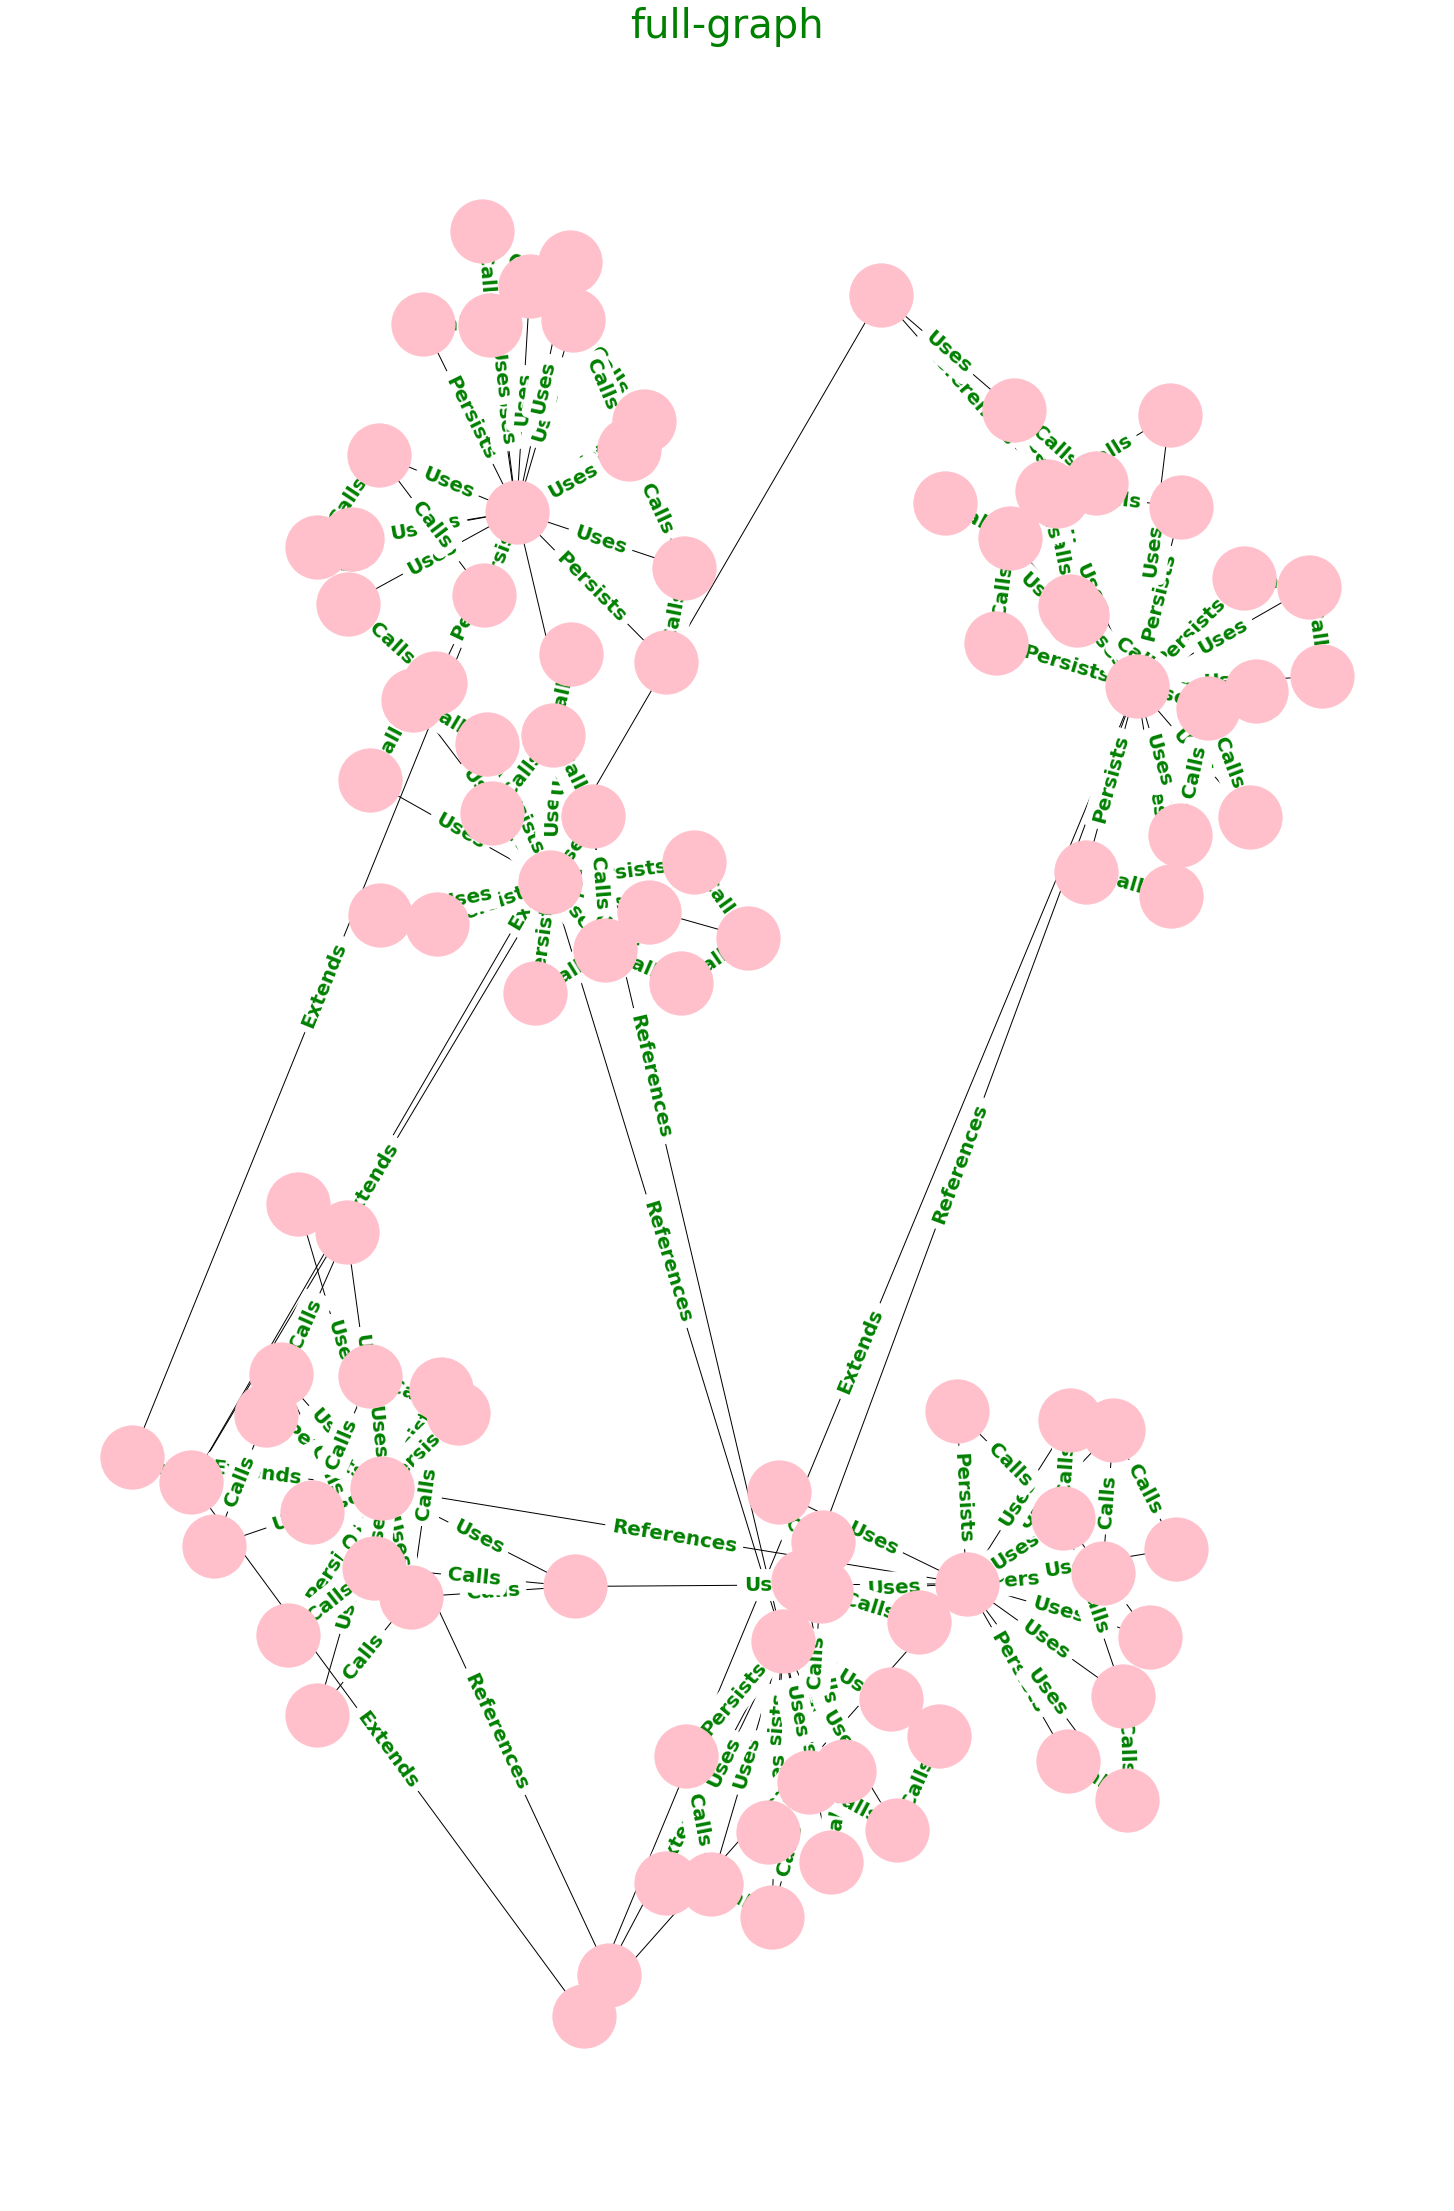

In [4]:
draw_graph(G,"full-graph")

In [5]:

subEdges = [(u,v,d) for u,v,d in G.edges(data = True) if d['rel_type'] in ['Extends','References']]
#subG.add_edges_from(subEdges)
subEdges

[('2', '7', {'rel_type': 'References', 'weight': 0.2}),
 ('2', '6', {'rel_type': 'Extends', 'weight': 0.0}),
 ('2', '12', {'rel_type': 'References', 'weight': 0.2}),
 ('3', '11', {'rel_type': 'References', 'weight': 0.2}),
 ('3', '8', {'rel_type': 'References', 'weight': 0.2}),
 ('3', '10', {'rel_type': 'References', 'weight': 0.2}),
 ('3', '13', {'rel_type': 'Extends', 'weight': 0.0}),
 ('4', '6', {'rel_type': 'Extends', 'weight': 0.0}),
 ('4', '9', {'rel_type': 'Extends', 'weight': 0.0}),
 ('4', '10', {'rel_type': 'Extends', 'weight': 0.0}),
 ('4', '13', {'rel_type': 'Extends', 'weight': 0.0}),
 ('5', '9', {'rel_type': 'References', 'weight': 0.2}),
 ('6', '8', {'rel_type': 'Extends', 'weight': 0.0}),
 ('7', '13', {'rel_type': 'Extends', 'weight': 0.0}),
 ('11', '13', {'rel_type': 'Extends', 'weight': 0.0})]

In [6]:
subNodes = set()
for nd in subEdges:
    subNodes.add(nd[0])
    subNodes.add(nd[1])
    #print( nd[0], nd[1])    
    
#print(subNodes.sort())
subNodes = sorted(subNodes,key=int)
#print(sorted(subNodes,key=int))
subNodes

['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']

In [7]:
len(subNodes)

12

In [8]:
subG = nx.Graph()
for n in G.nodes(data=True):
    if (n[0] in subNodes):
        print(f"{n}")
        #subG.add_node(n[0])
        subG.add_nodes_from([n])
        #subG.add_nodes_from(subNodes) error

('2', {'name': 'Vet', 'type': 'Entity'})
('3', {'name': 'Pet', 'type': 'Entity'})
('4', {'name': 'BaseEntity', 'type': 'Entity'})
('5', {'name': 'User', 'type': 'Entity'})
('6', {'name': 'Person', 'type': 'Entity'})
('7', {'name': 'Specialty', 'type': 'Entity'})
('8', {'name': 'Owner', 'type': 'Entity'})
('9', {'name': 'Role', 'type': 'Entity'})
('10', {'name': 'Visit', 'type': 'Entity'})
('11', {'name': 'PetType', 'type': 'Entity'})
('12', {'name': 'Vets', 'type': 'Entity'})
('13', {'name': 'NamedEntity', 'type': 'Entity'})


In [9]:
nodeLabeldict = {}
#nodeLabeldict = dict(subG.nodes(data=True))
#print(labeldict['41']['type'])

for i,v in subG.nodes(data=True):
    print(i,v,v['name'])
    nodeLabeldict[i] = v['name']


2 {'name': 'Vet', 'type': 'Entity'} Vet
3 {'name': 'Pet', 'type': 'Entity'} Pet
4 {'name': 'BaseEntity', 'type': 'Entity'} BaseEntity
5 {'name': 'User', 'type': 'Entity'} User
6 {'name': 'Person', 'type': 'Entity'} Person
7 {'name': 'Specialty', 'type': 'Entity'} Specialty
8 {'name': 'Owner', 'type': 'Entity'} Owner
9 {'name': 'Role', 'type': 'Entity'} Role
10 {'name': 'Visit', 'type': 'Entity'} Visit
11 {'name': 'PetType', 'type': 'Entity'} PetType
12 {'name': 'Vets', 'type': 'Entity'} Vets
13 {'name': 'NamedEntity', 'type': 'Entity'} NamedEntity


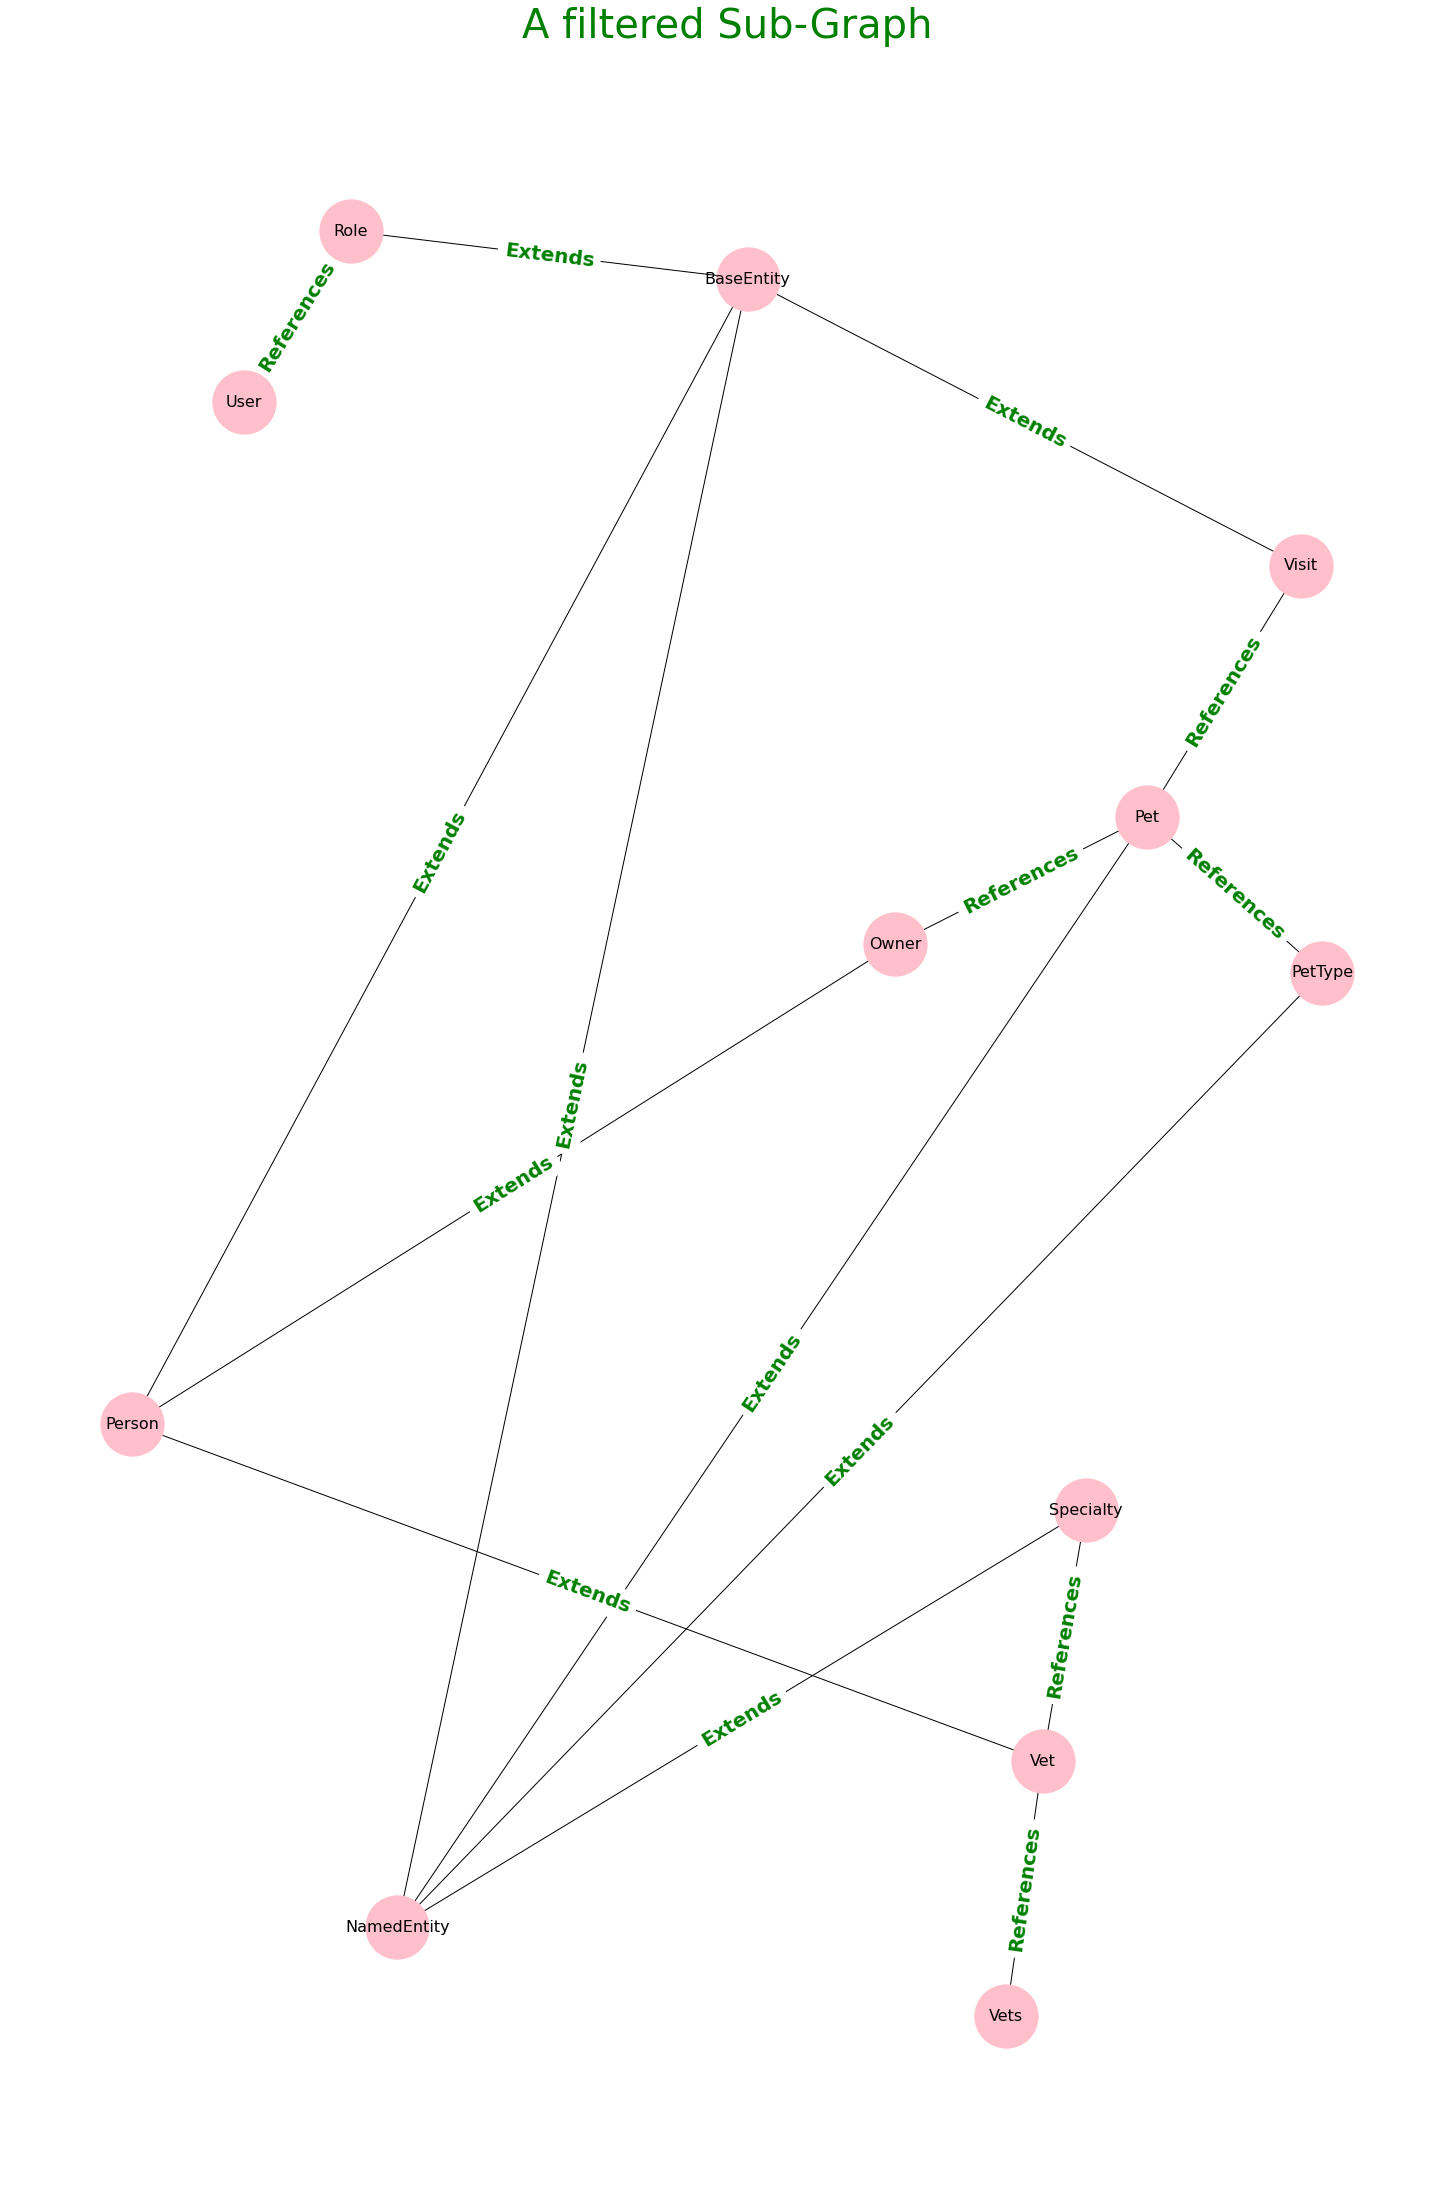

In [10]:
subG.nodes(data=True)

subG.add_edges_from(subEdges)

draw_graph(subG,"A filtered Sub-Graph", nodeLabeldict)

In [11]:
import community as community_louvain
import matplotlib.cm as cm

# compute the best partition  
#community.best_partition(graph, partition=None, weight='weight', resolution=1.0, randomize=None, random_state=None)
partition = community_louvain.best_partition(subG,None,'',1.0,None,None)
print(partition)
#print(max(partition.values()))
#print(partition.values())
#print(partition.keys())

{k: v for k, v in sorted(partition.items(), key=lambda item: item[1])}


{'2': 0, '3': 1, '4': 3, '5': 3, '6': 2, '7': 0, '8': 2, '9': 3, '10': 3, '11': 1, '12': 0, '13': 1}


{'2': 0,
 '7': 0,
 '12': 0,
 '3': 1,
 '11': 1,
 '13': 1,
 '6': 2,
 '8': 2,
 '4': 3,
 '5': 3,
 '9': 3,
 '10': 3}

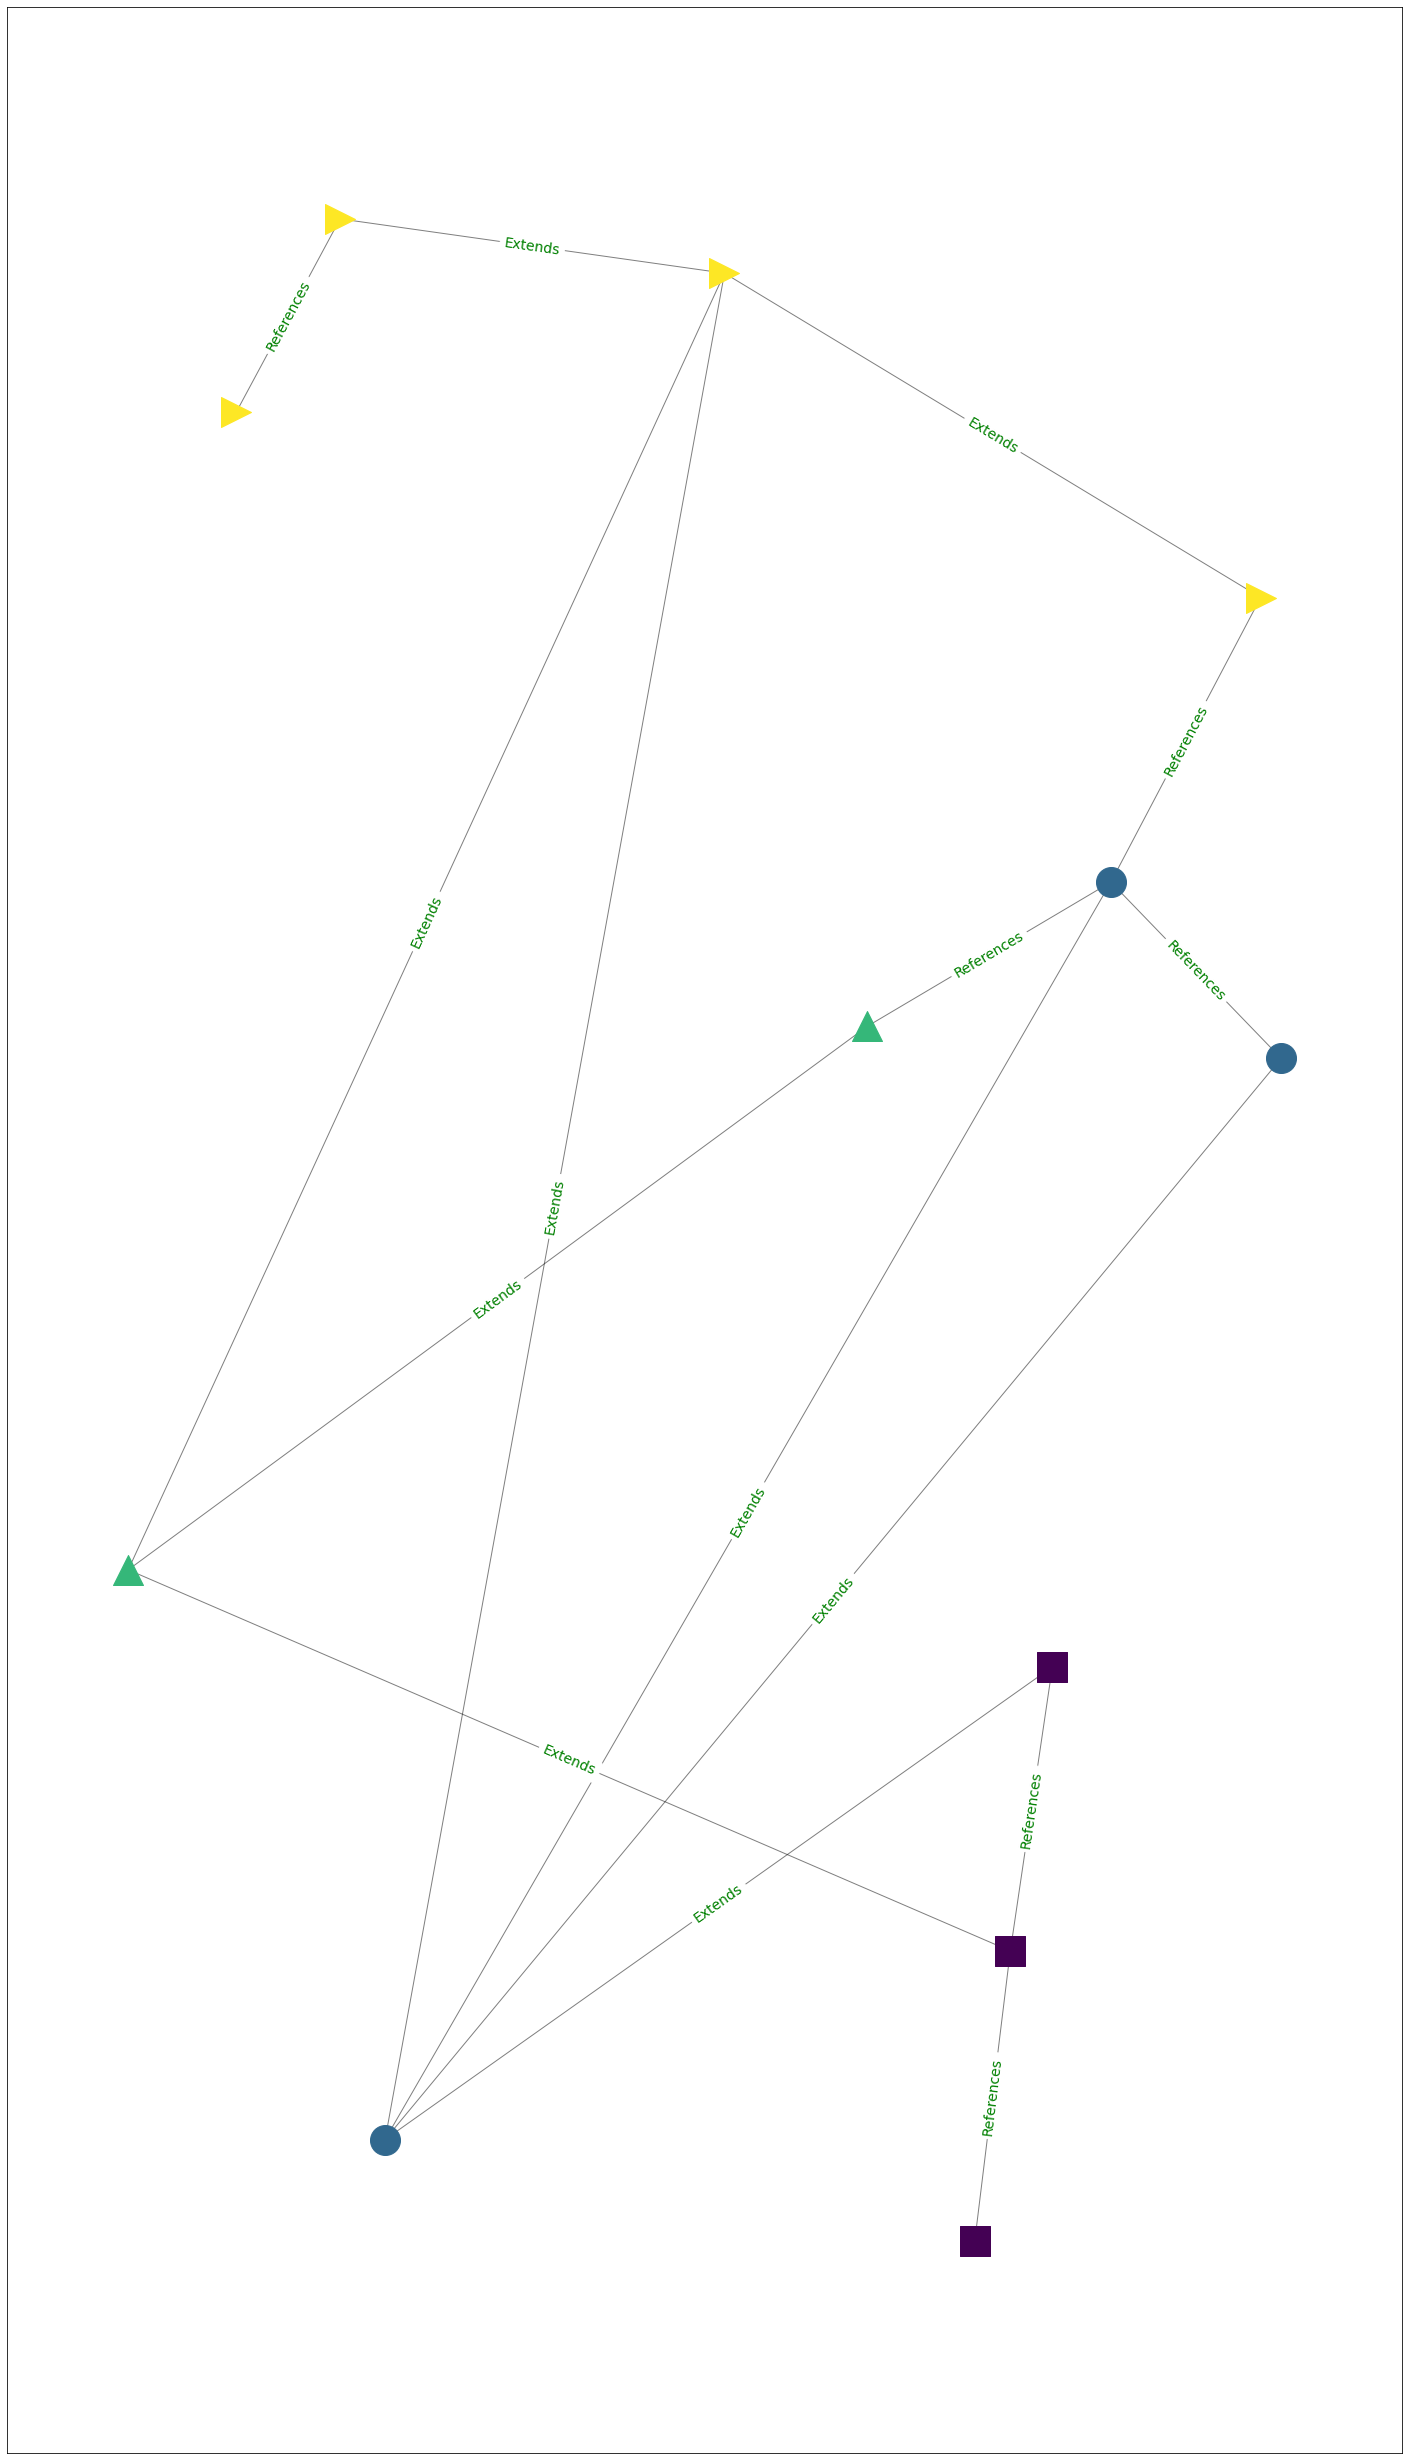

In [12]:
shapes = 'so^>v<dph8'

# draw the graph
pos = nx.spring_layout(subG, k=0.3, iterations=50, seed=2)      #pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2) 
plt.figure(1, figsize=(25,45))

# color the nodes according to their partition
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)

edge_labels = dict([((n1, n2), d['rel_type'])
                    for n1, n2, d in subG.edges(data=True)])
#edge_labels
nx.draw_networkx_edges(subG, pos, alpha=0.5)
nx.draw_networkx_edge_labels(partition, pos, edge_labels=edge_labels, label_pos=0.5, font_color='green', font_size=14, font_weight='normal')

for node, clstr in partition.items():
    nx.draw_networkx_nodes(partition, pos, [node], node_size=900,
                           node_color=[cmap.colors[clstr]],
                           node_shape=shapes[clstr])

#nx.draw(subG,
        #[node], 
 #       pos,
 #       node_color='pink',
 #       node_size=4000,
 #       labels=nodeLabeldict,
 #       with_labels=True,
 #       font_size = 10,
 #       font_color='black',
 #       font_weight='normal')
plt.show()

In [13]:
subG.number_of_nodes() #102

12

In [14]:
list(subG.nodes.data())[0:10:None]

[('2', {'name': 'Vet', 'type': 'Entity'}),
 ('3', {'name': 'Pet', 'type': 'Entity'}),
 ('4', {'name': 'BaseEntity', 'type': 'Entity'}),
 ('5', {'name': 'User', 'type': 'Entity'}),
 ('6', {'name': 'Person', 'type': 'Entity'}),
 ('7', {'name': 'Specialty', 'type': 'Entity'}),
 ('8', {'name': 'Owner', 'type': 'Entity'}),
 ('9', {'name': 'Role', 'type': 'Entity'}),
 ('10', {'name': 'Visit', 'type': 'Entity'}),
 ('11', {'name': 'PetType', 'type': 'Entity'})]